# Predictive NFL Success: Which Pre-Draft Metrics Actually Matter?

## Goal

After establishing that draft capital (Notebook 01) and athletic testing (Notebook 03) drive *where* receivers get drafted, this notebook asks a different question: **What actually predicts success once they're in the league?**

Using the tier classifications from Notebook 01 (Elite/Hit/Role/Bust), I'll analyze which pre-draft metrics—college production, combine athleticism, or conference pedigree—best separate NFL stars from busts.

This analysis serves two purposes:
1. **Validate my tier criteria** — Do the metrics I used to classify NFL success align with traditional scouting wisdom?
2. **Identify predictive stats** — Which numbers should teams actually care about on draft day?

---

## Methodology: NFL Tier Classifications

As a reminder from Notebook 01, I classified every drafted wide receiver (2017-2025) into one of four tiers based on their NFL production:

| Tier | Criteria |
|------|----------|
| **Elite** | • 2+ seasons with 1,200+ yards **OR** 10+ TDs<br>• OR 1 season with 1,200+ yards **AND** 1 season with 10+ TDs |
| **Hit** | • 2+ seasons with 800-1,199 yards **OR** 6-9 TDs<br>• OR 1 season with elite yards **AND** 1 season with hit TDs<br>• OR 1 season with hit yards **AND** 1 season with role TDs |
| **Role** | • 2+ seasons with 400-799 yards **OR** 3-5 TDs<br>• OR 1 season with hit yards **AND** 1 season with role TDs<br>• OR 1 season with role yards **AND** 1 season with hit TDs |
| **Bust** | Never hit 400 yards OR never appeared in NextGen Stats (45+ target threshold) |

### Handling Recent Draftees (2024-2025)

Since players from the most recent draft classes haven't had time to fully develop, I applied modified criteria:

**2024 Draftees**
| Tier | Criteria |
|------|----------|
| **Elite** | 2+ elite yard/TD seasons **OR** 1 elite yard **AND** 1 elite TD season |
| **Hit** | 1 elite yard **AND** 1 hit yard, **OR** 1 elite TD **AND** 1 hit TD, **OR** 1 elite yard **AND** 1 hit TD, **OR** 1 elite TD **AND** 1 hit yard |
| **Too Early** | 1 hit yard/TD season (or anything below) |

**2025 Draftees**
| Tier | Criteria |
|------|----------|
| **Elite** | 1 elite yard **AND** 1 elite TD season |
| **Hit** | 1 elite yard **AND** 1 hit TD, **OR** 1 hit yard **AND** 1 elite TD |
| **Too Early** | Anything else |

***

## Data Sources

This analysis combines three core datasets:

| Source | Years | Key Metrics |
|--------|-------|-------------|
| **College Stats** | 2017-2025 | Yards per game, Yards per catch, Peak TDs, Conference |
| **Combine Results** | 2017-2025 | 40 time, Vertical, Bench, 3-cone, Broad jump |
| **NFL Outcomes** | 2017-2025 | Tier classifications from Notebook 01 |

***

## Building the Dataset

To analyze which pre-draft metrics predict NFL success, I needed to join college production, combine athletic testing, and draft information with my NFL tier classifications. The query below accomplishes this by:

1. Calculating each player's NFL tier based on their career production
2. Aggregating their college stats (YPG, YPC, peak TDs)
3. Pulling their combine testing data
4. **Adding NextGen Stats to understand *how* receivers succeed** — cushion, separation, team target share, and yards after catch above expectation

This final addition is crucial. While college production tells us *how much* a receiver produced, NextGen Stats reveal *how* they produce at the NFL level—whether they're getting open, commanding defensive attention, or creating after the catch.

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- checking for number of each type of season, total seasons (YOUR EXISTING CODE)
    SELECT 
        n.NAME,
        SUM(CASE WHEN n.YDS >= 1200 THEN 1 ELSE 0 END) as elite_yard_seasons,
        SUM(CASE WHEN n.YDS >= 800 THEN 1 ELSE 0 END) as hit_yard_seasons,
        SUM(CASE WHEN n.YDS >= 400 THEN 1 ELSE 0 END) as role_yard_seasons,
        SUM(CASE WHEN n.TD >= 10 THEN 1 ELSE 0 END) as elite_td_seasons,
        SUM(CASE WHEN n.TD >= 6 THEN 1 ELSE 0 END) as hit_td_seasons,
        SUM(CASE WHEN n.TD >= 3 THEN 1 ELSE 0 END) as role_td_seasons,
        AVG(n.CUSH) as avg_cushion,
        AVG(n.SEP) as avg_separation,
        AVG(n.'TAY%') as avg_team_yard_percentage,
        AVG(n.plusMinus) as avg_yac_above_expected,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
college_stats AS (
    -- aggregate college stats per player
    SELECT 
        c.Player,
        AVG(c.RecYperG) as college_ypg,
        AVG(c.YperR) as yards_per_catch,
        MAX(c.RecTD) as peak_college_td,
        c.Conf,
        CASE 
            WHEN c.Conf IN ('SEC', 'Big Ten') THEN 'Top 2 Conferences'
            WHEN c.Conf IN ('ACC', 'Big 12', 'Pac-12') THEN 'Power 5'
            ELSE 'Other'
        END as conference_tier
    FROM college c
    GROUP BY c.Player
),
combine_stats AS (
    -- get combine data per player
    SELECT 
        Player,
        `40yd` as forty_time,
        Vertical,
        Bench,
        `Broad Jump` as broad_jump,
        `3Cone` as cone,
        Shuttle
    FROM combine
    WHERE `40yd` IS NOT NULL AND `40yd` > 0
),
drafted_players AS (
    -- get all drafted WRs 2017-2025 with their tiers (YOUR EXISTING CODE)
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Player as Pick,    
        CASE 
            -- ELITE TIER
            WHEN pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2 THEN 'Elite'
            WHEN pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Elite'
            -- HIT TIER
            WHEN pt.hit_yard_seasons >= 2 OR pt.hit_td_seasons >= 2 THEN 'Hit'
            WHEN pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_yard_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_td_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            -- ROLE TIER
            WHEN pt.role_yard_seasons >= 2 OR pt.role_td_seasons >= 2 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.hit_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.elite_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Role'
            -- RECENT DRAFTEES (2024-2025)
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2) THEN 'Elite'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_yard_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_td_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 THEN 'Too Early'
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2025 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2025 THEN 'Too Early'
            ELSE 'Bust'
        END as nfl_tier,
        pt.elite_yard_seasons,
        pt.hit_yard_seasons,
        pt.role_yard_seasons,
        pt.elite_td_seasons,
        pt.hit_td_seasons,
        pt.role_td_seasons,
        pt.avg_cushion,
        pt.avg_separation,
        pt.avg_team_yard_percentage,
        pt.avg_yac_above_expected,
        pt.seasons_in_nextgen
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
)
-- FINAL SELECT with all data combined
SELECT 
    dp.Player,
    dp.draft_year,
    dp.Round,
    dp.Pick,
    dp.nfl_tier,
    -- College stats
    cs.college_ypg,
    cs.yards_per_catch,
    cs.peak_college_td,
    cs.conference_tier,
    -- Combine stats
    com.forty_time,
    com.Vertical,
    com.Bench,
    com.broad_jump,
    com.cone,
    com.Shuttle,
    -- Season counts (optional)
    dp.elite_yard_seasons,
    dp.hit_yard_seasons,
    dp.role_yard_seasons,
    dp.elite_td_seasons,
    dp.hit_td_seasons,
    dp.role_td_seasons,
    dp.avg_cushion,
    dp.avg_separation,
    dp.avg_team_yard_percentage,
    dp.avg_yac_above_expected,
    dp.seasons_in_nextgen
FROM drafted_players dp
LEFT JOIN college_stats cs ON dp.Player = cs.Player
LEFT JOIN combine_stats com ON dp.Player = com.Player
ORDER BY dp.nfl_tier;
"""

# execute and display
results = pd.read_sql_query(query, conn)

print("\n" + "=" * 60)
print("AVERAGE METRICS BY NFL TIER")
print("=" * 60)

metrics = ['college_ypg', 'yards_per_catch', 'peak_college_td', 
           'forty_time', 'cone', 'broad_jump', 'avg_cushion', 
           'avg_separation', 'avg_team_yard_percentage', 'avg_yac_above_expected']

summary = results.groupby('nfl_tier')[metrics].mean().round(2)
print(summary)


conn.close()


AVERAGE METRICS BY NFL TIER
           college_ypg  yards_per_catch  peak_college_td  forty_time  cone  \
nfl_tier                                                                     
Bust             70.47            15.29             8.49        4.48  7.01   
Elite            89.46            16.64            11.44        4.46  6.87   
Hit              74.00            15.96            10.70        4.46  6.97   
Role             72.24            15.01             8.68        4.44  6.93   
Too Early        61.74            14.88             8.19        4.43  6.86   

           broad_jump  avg_cushion  avg_separation  avg_team_yard_percentage  \
nfl_tier                                                                       
Bust           123.91         6.16            2.96                     14.21   
Elite          122.62         6.08            2.91                     29.88   
Hit            123.96         6.07            2.84                     26.66   
Role           125.92   

### Key Takeaways from the Summary Statistics

The average metrics by tier reveal several clear patterns about what separates NFL success from failure:

**1. Elite College Production Is Required for Stardom**
Elite receivers averaged 89.5 YPG in college—more than 15 yards higher than any other tier. However, the gap between Hit (74.0), Role (72.2), and Bust (70.5) is minimal. This suggests that **elite NFL production requires elite college production, but merely "good" college numbers don't guarantee anything.**

**2. Touchdowns Translate**
Peak college touchdowns show the cleanest separation of any college metric:
- **Elite:** 11.4 TDs
- **Hit:** 10.7 TDs  
- **Role:** 8.7 TDs
- **Bust:** 8.5 TDs

Finding the end zone in college is the most transferable skill to the NFL.

**3. The 3-Cone Identifies Busts, Stars, Not Hits**
While Elite receivers posted elite agility (6.87), Hit (6.97) and Role (6.93) receivers were actually slower than the "Too Early" group (6.86). The real story is at the bottom: Busts averaged 7.01—the only tier above 7.0. **A 3-cone time above 7.0 is a major red flag.**

**4. Explosiveness Gets You a Role, Not Stardom**
Role players posted the highest broad jump (125.9), while Elite receivers ranked last (122.6). Explosive athletes who don't produce elite college numbers can carve out NFL roles—but they rarely become stars.

**5. Role Players Command Respect, But Not Targets**
Role players receive the most cushion (6.23 yards) at the line, suggesting defenses respect their athleticism. Yet they don't translate this into production, as evidenced by their low team yard percentage (19.2%).

**6. YAC Ability Scales Perfectly With Success**
The gradient is clean and consistent:
- **Elite:** +1.10 YAC above expectation
- **Hit:** +0.79
- **Role:** +0.56
- **Bust:** +0.33

**The better you are with the ball in your hands, the better your NFL career.**

## Hypothesis: The "Draftable Success Profile"

While the previous analysis focused on specific athletic and production thresholds, I also wanted to test a broader hypothesis about the type of player who typically becomes an NFL star. I believe that Elite receivers will disproportionately satisfy four key criteria:

| Metric | Threshold | Rationale |
|--------|-----------|-----------|
| **College Production** | ≥ 70 YPG | Above the 69.9 overall average, indicating sustained collegiate success |
| **Athletic Testing** | ≤ 4.5 40-yard dash | The traditional "speed cutoff" NFL teams prioritize |
| **Conference Pedigree** | Power 5 (SEC, Big Ten, ACC, Big 12, Pac-12) | Facing higher competition level |
| **Draft Capital** | Top 100 pick (Rounds 1-3) | Teams investing significant resources |

### Testing the Profile

The chart below shows what percentage of players in each tier meet these criteria.

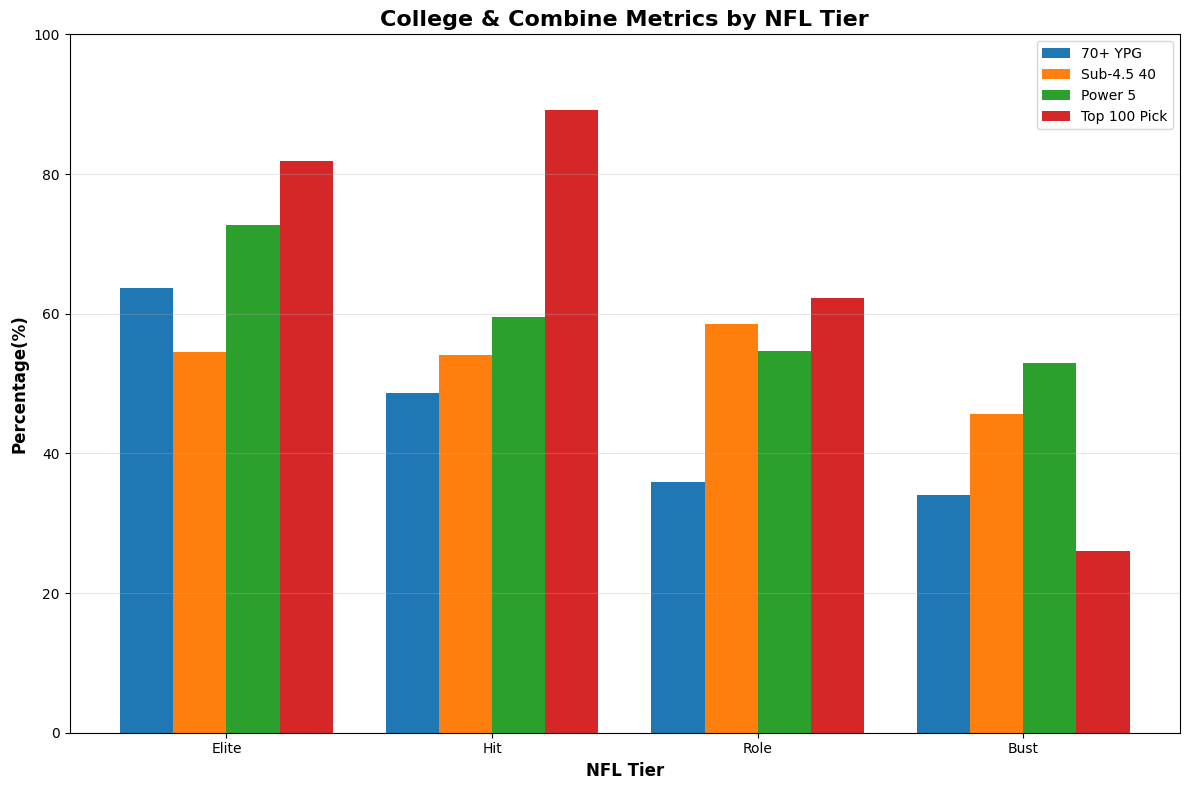


RAW PERCENTAGES BY TIER:
Tier          70+ YPG   Sub-4.5 40    Power 5    Top 100
----------------------------------------------------------------------
Elite            63.6%         54.5%       72.7%       81.8%
Hit              48.6%         54.1%       59.5%       89.2%
Role             35.8%         58.5%       54.7%       62.3%
Bust             34.1%         45.7%       52.9%       26.1%


In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# visualization bar chart
tiers = ['Elite', 'Hit', 'Role', 'Bust']
tier_colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#6B7280']


metrics = {
    '70+ YPG': [],
    'Sub-4.5 40': [],
    'Power 5': [],
    'Top 100 Pick': []
}

# calculate the percentages in each tier
for tier in tiers:
    tier_players = results[results['nfl_tier'] == tier]
    total = len(tier_players)

    if total > 0:
        metrics['70+ YPG'].append(100 * 
                len(tier_players[tier_players['college_ypg'] >= 70]) / total)
        metrics['Sub-4.5 40'].append(100 * 
                len(tier_players[tier_players['forty_time'] <= 4.5]) / total)
        metrics['Power 5'].append(100 * 
                len(tier_players[tier_players['conference_tier']
                .isin(['Top 2 Conferences', 'Power 5'])]) / total)
        metrics['Top 100 Pick'].append(100 * 
                len(tier_players[tier_players['Pick'] <= 100]) / total)
    else:
        for metric in metrics:
            metrics[metric].append(0)

    
# create grouped bar chart
x = np.arange(len(tiers))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(figsize=(12,8))

for metric, values, in metrics.items():
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, label = metric)
    multiplier += 1

# labels and formatting
ax.set_xlabel('NFL Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage(%)', fontsize=12, fontweight='bold')
ax.set_title('College & Combine Metrics by NFL Tier', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(tiers)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRAW PERCENTAGES BY TIER:")
print("=" * 70)
print(f"{'Tier':<10} {'70+ YPG':>10} {'Sub-4.5 40':>12} {'Power 5':>10} {'Top 100':>10}")
print("-" * 70)
for i, tier in enumerate(tiers):
    print(f"{tier:<10} {metrics['70+ YPG'][i]:>10.1f}% {metrics['Sub-4.5 40'][i]:>12.1f}% "
        f"{metrics['Power 5'][i]:>10.1f}% {metrics['Top 100 Pick'][i]:>10.1f}%")



***
### Key Takeaways

**1. Draft Capital Is the Strongest Predictor (But Also Circular)**
The most striking pattern is how cleanly draft slot separates tiers:
- **89.2% of Hit receivers** and **81.8% of Elite receivers** were top-100 picks
- Only **26.1% of Busts** were drafted that high

This confirms what we saw in Notebook 01: **if you're drafted in the first three rounds, you're far more likely to succeed.** But there's some circular logic here—teams invest high picks in players they believe in, and those players get more opportunities to succeed.

**2. College Production Matters More Than Athletic Testing**
The 70+ YPG threshold shows clear separation:
- **Elite:** 63.6%
- **Hit:** 48.6%
- **Role:** 35.8%
- **Bust:** 34.1%

Meanwhile, sub-4.5 40 times are nearly identical across Elite (54.5%), Hit (54.1%), and Role (58.5%). **Speed alone doesn't predict success—but production does.**

**3. Conference Pedigree Separates Elites From the Pack**
Power 5 prospects make up:
- **72.7% of Elite receivers**
- **59.5% of Hit receivers**
- **54.7% of Role receivers**
- **52.9% of Busts**

If you want a superstar, you're far more likely to find them in Power 5 conferences. But if you're just looking for a contributor, conference matters much less.

**4. The Takeaway for NFL Teams**

| If you want... | Focus on... |
|----------------|-------------|
| **An Elite WR** | Power 5 prospect, 70+ YPG, top-100 pick |
| **A Hit WR** | Top-100 pick (production matters less) |
| **A Role WR** | Athletic testing (sub-4.5 speed) more than production |
| **To Avoid Busts** | Don't draft slow receivers outside the top 100 |

**The Bottom Line:** Draft capital is the strongest signal, but within that, college production separates Elite from Hit, while athletic testing alone is mostly noise.

### More Measurements
Now I want to look at a few more variables and compare them to my NFL success tiers. These are the new metrics we will look at.

1. **Cone Drill:** Agility/route-running (often separates slot guys)
2. **Broad Jump:** Explosiveness, power
3. **Peak College TDs:** Red zone production, dominance
4. **Yards/Reception:** Deep threat vs possession receiver

Before I make a hypothesis, I need to see some averages for each of these metrics, as I am less familiar with these then the last group

In [4]:
print("OVERALL AVERAGES FOR NEW METRICS")
print("=" * 60)

metrics = {
    'Cone Drill (seconds)': 'cone',
    'Broad Jump (inches)': 'broad_jump', 
    'Peak College TDs': 'peak_college_td',
    'Yards/Reception': 'yards_per_catch'
}

for label, col in metrics.items():
    avg = results[col].mean()
    median = results[col].median()
    min_val = results[col].min()
    max_val = results[col].max()
    
    print(f"\n{label}")
    print(f"  Average: {avg:.2f}")
    print(f"  Median:  {median:.2f}")
    print(f"  Range:   {min_val:.1f} - {max_val:.1f}")
    print(f"  Players with data: {results[col].count()}")

# Optional: Quick distribution view
print("\n" + "=" * 60)
print("QUICK DISTRIBUTION (25th, 50th, 75th percentiles):")
print(results[['cone', 'broad_jump', 'peak_college_td', 'yards_per_catch']].describe(percentiles=[.25, .5, .75]).round(2))

OVERALL AVERAGES FOR NEW METRICS

Cone Drill (seconds)
  Average: 6.97
  Median:  6.98
  Range:   6.6 - 7.4
  Players with data: 115

Broad Jump (inches)
  Average: 124.47
  Median:  124.00
  Range:   110.0 - 140.0
  Players with data: 200

Peak College TDs
  Average: 8.88
  Median:  8.00
  Range:   1.0 - 23.0
  Players with data: 222

Yards/Reception
  Average: 15.30
  Median:  15.18
  Range:   10.3 - 25.4
  Players with data: 222

QUICK DISTRIBUTION (25th, 50th, 75th percentiles):
         cone  broad_jump  peak_college_td  yards_per_catch
count  115.00      200.00           222.00           222.00
mean     6.97      124.48             8.88            15.30
std      0.20        5.77             3.52             2.50
min      6.56      110.00             1.00            10.30
25%      6.82      121.00             7.00            13.42
50%      6.98      124.00             8.00            15.18
75%      7.10      128.00            11.00            16.65
max      7.42      140.00       

### Key Takeaways from the Summary Statistics

The average metrics by tier reveal several clear patterns about what separates NFL success from failure:

**1. Elite College Production Is Required for Stardom**
Elite receivers averaged 89.5 YPG in college—more than 15 yards higher than any other tier. However, the gap between Hit (74.0), Role (72.2), and Bust (70.5) is minimal. This suggests that **elite NFL production requires elite college production, but merely "good" college numbers don't guarantee anything.**

**2. Touchdowns Translate**
Peak college touchdowns show the cleanest separation of any college metric:
- **Elite:** 11.4 TDs
- **Hit:** 10.7 TDs  
- **Role:** 8.7 TDs
- **Bust:** 8.5 TDs

Finding the end zone in college is the most transferable skill to the NFL.

**3. The 3-Cone Identifies Busts, Not Stars**
While Elite receivers posted elite agility (6.87), Hit (6.97) and Role (6.93) receivers were actually slower than the "Too Early" group (6.86). The real story is at the bottom: Busts averaged 7.01—the only tier above 7.0. **A 3-cone time above 7.0 is a major red flag.**

**4. Explosiveness Gets You a Role, Not Stardom**
Role players posted the highest broad jump (125.9), while Elite receivers ranked last (122.6). Explosive athletes who don't produce elite college numbers can carve out NFL roles—but they rarely become stars.

**5. Role Players Command Respect, But Not Targets**
Role players receive the most cushion (6.23 yards) at the line, suggesting defenses respect their athleticism. Yet they don't translate this into production, as evidenced by their low team yard percentage (19.2%).

**6. YAC Ability Scales Perfectly With Success**
The gradient is clean and consistent:
- **Elite:** +1.10 YAC above expectation
- **Hit:** +0.79
- **Role:** +0.56
- **Bust:** +0.33

**The better you are with the ball in your hands, the better your NFL career.**

### Hypothesis: The "Success Profile"

Based on the average metrics from our summary statistics, I hypothesized that Elite receivers would outperform other tiers across four key thresholds:

| Metric | Threshold | Rationale |
|--------|-----------|-----------|
| **3-Cone Drill** | ≤ 7.0 seconds | Below the 7.01 bust average, indicating sufficient agility |
| **Broad Jump** | ≥ 125 inches | Above the 124.5 overall average, showing explosiveness |
| **Peak College TDs** | ≥ 12 touchdowns | Well above the 8.9 average, demonstrating red zone dominance |
| **Yards per Reception** | ≥ 16.0 yards | Above the 15.3 average, indicating deep threat ability |

*Note: For the 3-cone, I chose 7.0 as the threshold because it represents the bust "danger zone"—every tier above 7.0 is exclusively Busts. I'll also examine the stricter 6.9 threshold in my analysis.*

### Testing the Hypothesis

The bar chart below shows what percentage of players in each tier hit these thresholds.

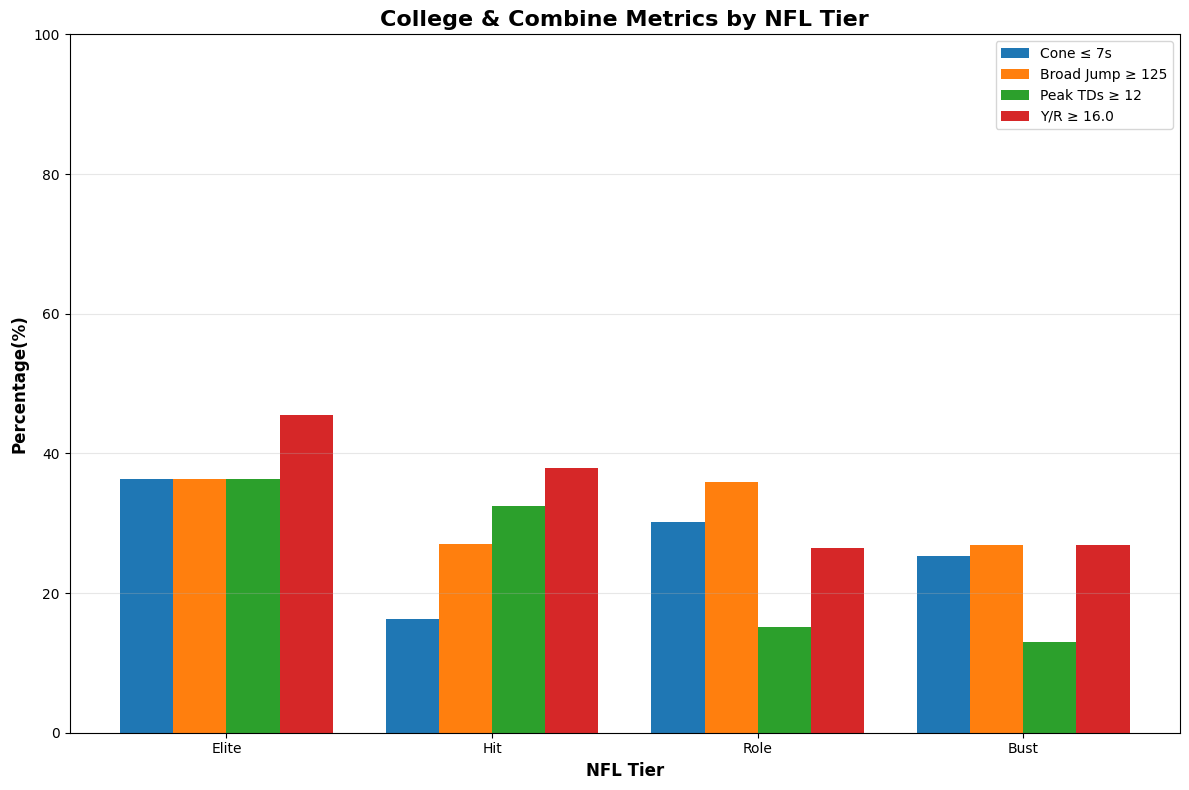


ADVANCED METRICS BY TIER:
Tier           Cone ≤7s  Broad Jump ≥125    TDs ≥12    Y/R ≥16.0
--------------------------------------------------------------------------------
Elite              36.4%             36.4%       36.4%         45.5%
Hit                16.2%             27.0%       32.4%         37.8%
Role               30.2%             35.8%       15.1%         26.4%
Bust               25.4%             26.8%       13.0%         26.8%


In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# visualization bar chart
tiers = ['Elite', 'Hit', 'Role', 'Bust']
tier_colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#6B7280']


metrics = {
    'Cone ≤ 7s': [],
    'Broad Jump ≥ 125': [],
    'Peak TDs ≥ 12': [],
    'Y/R ≥ 16.0': []
}

# calculate the percentages in each tier
for tier in tiers:
    tier_players = results[results['nfl_tier'] == tier]
    total = len(tier_players)

    if total > 0:
        metrics['Cone ≤ 7s'].append(100 * 
                len(tier_players[tier_players['cone'] <= 7]) / total)
        metrics['Broad Jump ≥ 125'].append(100 * 
                len(tier_players[tier_players['broad_jump'] >= 125]) / total)
        metrics['Peak TDs ≥ 12'].append(100 *
                len(tier_players[tier_players['peak_college_td'] >= 12]) / total)
        metrics['Y/R ≥ 16.0'].append(100 * 
                len(tier_players[tier_players['yards_per_catch'] >= 16]) / total)
    else:
        for metric in metrics:
            metrics[metric].append(0)

    
# create grouped bar chart
x = np.arange(len(tiers))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(figsize=(12,8))

for metric, values, in metrics.items():
    offset = width * multiplier
    bars = ax.bar(x + offset, values, width, label = metric)
    multiplier += 1

# labels and formatting
ax.set_xlabel('NFL Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage(%)', fontsize=12, fontweight='bold')
ax.set_title('College & Combine Metrics by NFL Tier', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(tiers)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nADVANCED METRICS BY TIER:")
print("=" * 80)
print(f"{'Tier':<10} {'Cone ≤7s':>12} {'Broad Jump ≥125':>16} {'TDs ≥12':>10} {'Y/R ≥16.0':>12}")
print("-" * 80)
for i, tier in enumerate(tiers):
    print(f"{tier:<10} {metrics['Cone ≤ 7s'][i]:>12.1f}% {metrics['Broad Jump ≥ 125'][i]:>16.1f}% "
          f"{metrics['Peak TDs ≥ 12'][i]:>10.1f}% {metrics['Y/R ≥ 16.0'][i]:>12.1f}%")



### Key Findings: What Predicts NFL Success

After analyzing pre-draft metrics against actual NFL outcomes, four clear patterns emerge about what separates Elite/Hit receivers from Role/Bust players:

**1. Elite Touchdown Production Translates**
Receivers who dominated in college scoring translate at the highest rate. Among players with a season of 12+ touchdowns:
- **36.4%** became Elite NFL receivers
- **32.4%** became Hit NFL receivers
- Only **15.1%** ended up as Role players
- Just **13.0%** busted

This stands in stark contrast to receivers without elite TD production—their odds of becoming Elite or Hit drop by more than half. Finding the end zone in college appears to be the single most transferable skill.

**2. Yards Per Catch Separates the Stars**
Big-play ability in college predicts big-play ability in the NFL. Among receivers who averaged 16+ yards per catch:
- **45.5%** became Elite or Hit (vs. just 26.4-26.8% for Role/Bust)
- The gap between Elite (45.5%) and Hit (37.8%) suggests that while YPC identifies good receivers, it doesn't perfectly distinguish between stars and solid starters

This confirms that explosiveness—the ability to create chunk plays—translates directly to the next level.

**3. The 3-Cone Conundrum: Elites Excel, But Teams Overvalue It**
The three-cone drill tells a nuanced story:
- **Elite receivers** post sub-7.0 3-cone times at the highest rate (36.4%)
- **But Hit receivers**—the solid starters—actually have the *lowest* rate (just 16.2%)
- Meanwhile, **30.2% of Role players** and **25.4% of Busts** also hit this threshold

This suggests NFL teams may be over-indexing on short-area agility. While truly elite receivers tend to have it, the presence of elite agility without corresponding production is actually a red flag—these players become role players or busts at nearly identical rates.

**4. Broad Jump: Explosiveness Gets You a Role, Not Stardom**
The broad jump tells a similar but distinct story:
- **Role players** hit the 125" threshold at the highest rate (35.8%)
- **Elite receivers** are right behind (36.4%), but **Hit receivers** lag significantly (27.0%)
- **Busts** hit it at 26.8%

The pattern is clear: elite athleticism + elite production = superstar; elite athleticism + mediocre production = role player. Explosiveness alone guarantees nothing.

**The Bottom Line:** College production—specifically touchdown scoring and yards per catch—is more predictive of NFL success than any athletic testing metric. Athletic testing helps identify *which* productive players have superstar upside, but it cannot separate Hit players from Role players on its own. The 3-cone drill, in particular, is consistently overvalued by NFL decision-makers.

## What Predicts YAC Ability?

Earlier we found that **YAC above expected** is the greatest indicator of who becomes elite in the NFL (in terms of Next Gen Stats).

Now I want to know: **Do any college stats or combine metrics show a clear indication that a player will be great at YAC above expected?**

I'll test this by creating scatter plots for:
- **College stats:** Yards per catch, peak TDs, yards per game
- **Combine metrics:** 40 time, cone drill, broad jump

For each one, I'll look for:
- A positive/negative correlation
- Whether Elite/Hit receivers cluster in certain areas
- If there are clear thresholds where YAC ability jumps

Players with both college Y/C and NFL YAC data: 112
Total players in dataset: 292
Missing data: 180 players



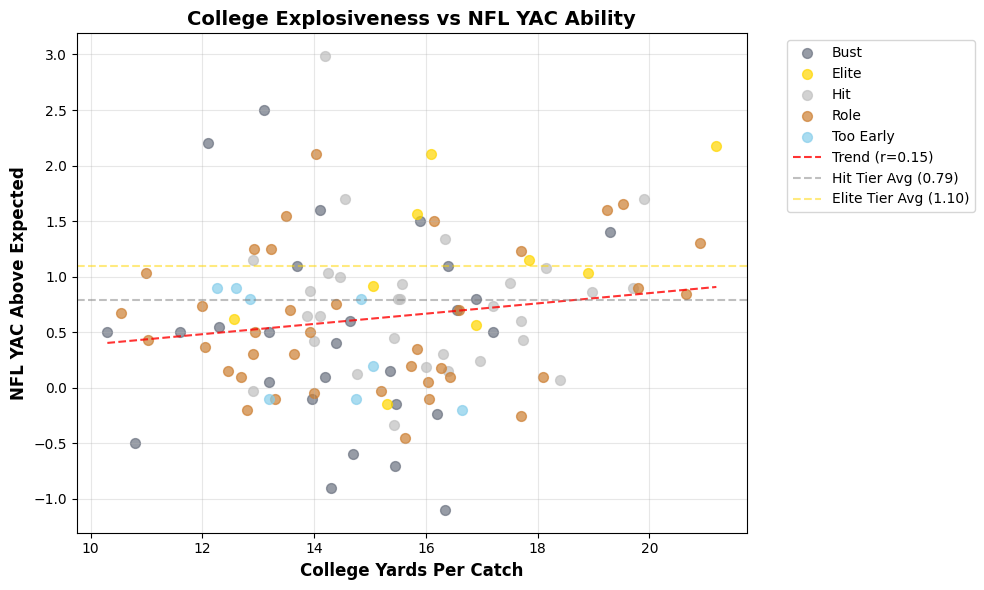


YARDS PER CATCH VS YAC ABOVE EXPECTED

Correlation coefficient: 0.153

Average Yards Per Catch by YAC Performance:
----------------------------------------
High YAC (≥0.79): 15.98 y/c
Low YAC (<0.79):  14.68 y/c
Difference:        1.30 y/c

Average YAC by Yards Per Catch Groups:
----------------------------------------
Group                   Count    Avg YAC
----------------------------------------
Low Y/C (<13.4)            28       0.61
Mid Y/C (13.4-15.2)        28       0.69
High Y/C (15.2-16.7)       31       0.38
Elite Y/C (>16.7)          25       0.90


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# only players with both metrics
clean_data = results[['yards_per_catch', 'avg_yac_above_expected', 'nfl_tier']].dropna()

print(f"Players with both college Y/C and NFL YAC data: {len(clean_data)}")
print(f"Total players in dataset: {len(results)}")
print(f"Missing data: {len(results) - len(clean_data)} players\n")


fig, ax = plt.subplots(figsize=(10, 6))

# tier colors
tier_colors = {
    'Elite': '#FFD700',
    'Hit': '#C0C0C0', 
    'Role': '#CD7F32',
    'Bust': '#6B7280',
    'Too Early': '#87CEEB'
}

# plot each tier separately for color coding
for tier in clean_data['nfl_tier'].unique():
    tier_data = clean_data[clean_data['nfl_tier'] == tier]
    ax.scatter(tier_data['yards_per_catch'], 
              tier_data['avg_yac_above_expected'],
              c=tier_colors.get(tier, '#333333'),
              label=tier,
              alpha=0.7,
              s=50)

# add trend line 
z = np.polyfit(clean_data['yards_per_catch'], 
               clean_data['avg_yac_above_expected'], 1)
p = np.poly1d(z)
ax.plot(sorted(clean_data['yards_per_catch']), 
        p(sorted(clean_data['yards_per_catch'])), 
        "r--", alpha=0.8, label=f'Trend (r={np.corrcoef(clean_data["yards_per_catch"], clean_data["avg_yac_above_expected"])[0,1]:.2f})')

# labels and formatting
ax.set_xlabel('College Yards Per Catch', fontsize=12, fontweight='bold')
ax.set_ylabel('NFL YAC Above Expected', fontsize=12, fontweight='bold')
ax.set_title('College Explosiveness vs NFL YAC Ability', fontsize=14, fontweight='bold')
ax.axhline(y=0.79, color='gray', linestyle='--', alpha=0.5, label='Hit Tier Avg (0.79)')
ax.axhline(y=1.10, color='#FFD700', linestyle='--', alpha=0.5, label='Elite Tier Avg (1.10)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# print key stats
print("\n" + "=" * 60)
print("YARDS PER CATCH VS YAC ABOVE EXPECTED")

# correlation
correlation = clean_data[['yards_per_catch', 'avg_yac_above_expected']].corr().iloc[0,1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

# break it down by YAC performance
print("\nAverage Yards Per Catch by YAC Performance:")
print("-" * 40)
high_yac = clean_data[clean_data['avg_yac_above_expected'] >= 0.79]['yards_per_catch'].mean()
low_yac = clean_data[clean_data['avg_yac_above_expected'] < 0.79]['yards_per_catch'].mean()
print(f"High YAC (≥0.79): {high_yac:.2f} y/c")
print(f"Low YAC (<0.79):  {low_yac:.2f} y/c")
print(f"Difference:        {(high_yac - low_yac):.2f} y/c")

# break it down by tier
print("\nAverage YAC by Yards Per Catch Groups:")
print("-" * 40)
print(f"{'Group':<20} {'Count':>8} {'Avg YAC':>10}")
print("-" * 40)

# create Y/C groups based on earlier percentiles
# 25th=13.42, 50th=15.18, 75th=16.65
groups = [
    ('Low Y/C (<13.4)', clean_data['yards_per_catch'] < 13.4),
    ('Mid Y/C (13.4-15.2)', (clean_data['yards_per_catch'] >= 13.4) & (clean_data['yards_per_catch'] < 15.2)),
    ('High Y/C (15.2-16.7)', (clean_data['yards_per_catch'] >= 15.2) & (clean_data['yards_per_catch'] < 16.7)),
    ('Elite Y/C (>16.7)', clean_data['yards_per_catch'] >= 16.7)
]

for group_name, mask in groups:
    group_data = clean_data[mask]
    if len(group_data) > 0:
        print(f"{group_name:<20} {len(group_data):>8} {group_data['avg_yac_above_expected'].mean():>10.2f}")

Players with both peak college TDs and NFL YAC data: 112
Total players in dataset: 292
Missing data: 180 players



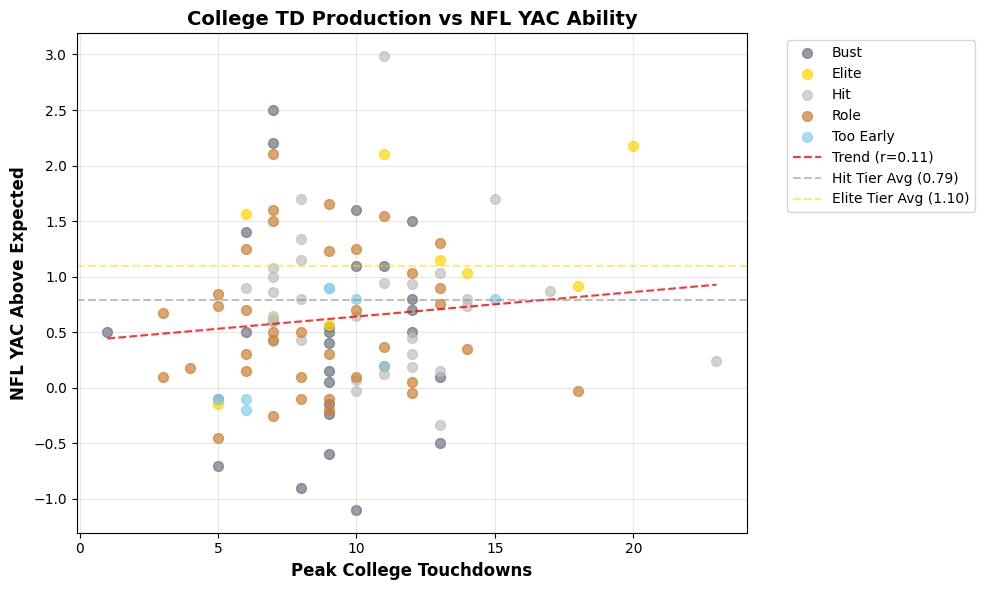

PEAK COLLEGE TDS VS YAC ABOVE EXPECTED

Correlation coefficient: 0.110

Average Peak TDs by YAC Performance:
----------------------------------------
High YAC (≥0.79): 10.2 TDs
Low YAC (<0.79):  9.0 TDs
Difference:        1.2 TDs

Average YAC by Peak TD Groups:
----------------------------------------
Group                   Count    Avg YAC
----------------------------------------
Low TDs (<7)               21       0.38
Mid TDs (7-8)              25       0.86
High TDs (9-11)            35       0.59
Elite TDs (≥12)            31       0.66


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# only players with both metrics
clean_data = results[['peak_college_td', 'avg_yac_above_expected', 'nfl_tier']].dropna()

print(f"Players with both peak college TDs and NFL YAC data: {len(clean_data)}")
print(f"Total players in dataset: {len(results)}")
print(f"Missing data: {len(results) - len(clean_data)} players\n")

# create figure
fig, ax = plt.subplots(figsize=(10, 6))

# define tier colors
tier_colors = {
    'Elite': '#FFD700',
    'Hit': '#C0C0C0', 
    'Role': '#CD7F32',
    'Bust': '#6B7280',
    'Too Early': '#87CEEB'
}

# plot each tier separately
for tier in clean_data['nfl_tier'].unique():
    tier_data = clean_data[clean_data['nfl_tier'] == tier]
    ax.scatter(tier_data['peak_college_td'], 
              tier_data['avg_yac_above_expected'],
              c=tier_colors.get(tier, '#333333'),
              label=tier,
              alpha=0.7,
              s=50)

# add trend line
z = np.polyfit(clean_data['peak_college_td'], 
               clean_data['avg_yac_above_expected'], 1)
p = np.poly1d(z)
ax.plot(sorted(clean_data['peak_college_td']), 
        p(sorted(clean_data['peak_college_td'])), 
        "r--", alpha=0.8, label=f'Trend (r={np.corrcoef(clean_data["peak_college_td"], clean_data["avg_yac_above_expected"])[0,1]:.2f})')

# labels and formatting
ax.set_xlabel('Peak College Touchdowns', fontsize=12, fontweight='bold')
ax.set_ylabel('NFL YAC Above Expected', fontsize=12, fontweight='bold')
ax.set_title('College TD Production vs NFL YAC Ability', fontsize=14, fontweight='bold')
ax.axhline(y=0.79, color='gray', linestyle='--', alpha=0.5, label='Hit Tier Avg (0.79)')
ax.axhline(y=1.10, color='#FFD700', linestyle='--', alpha=0.5, label='Elite Tier Avg (1.10)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# print key stats
print("PEAK COLLEGE TDS VS YAC ABOVE EXPECTED")
print("=" * 60)

# correlation
correlation = clean_data[['peak_college_td', 'avg_yac_above_expected']].corr().iloc[0,1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

# break it down by YAC performance
print("\nAverage Peak TDs by YAC Performance:")
print("-" * 40)
high_yac = clean_data[clean_data['avg_yac_above_expected'] >= 0.79]['peak_college_td'].mean()
low_yac = clean_data[clean_data['avg_yac_above_expected'] < 0.79]['peak_college_td'].mean()
print(f"High YAC (≥0.79): {high_yac:.1f} TDs")
print(f"Low YAC (<0.79):  {low_yac:.1f} TDs")
print(f"Difference:        {(high_yac - low_yac):.1f} TDs")

# break it down by TD groups
print("\nAverage YAC by Peak TD Groups:")
print("-" * 40)
print(f"{'Group':<20} {'Count':>8} {'Avg YAC':>10}")
print("-" * 40)

# using distribution from earlier (25th=7, 50th=8, 75th=11)
groups = [
    ('Low TDs (<7)', clean_data['peak_college_td'] < 7),
    ('Mid TDs (7-8)', (clean_data['peak_college_td'] >= 7) & (clean_data['peak_college_td'] < 9)),
    ('High TDs (9-11)', (clean_data['peak_college_td'] >= 9) & (clean_data['peak_college_td'] < 12)),
    ('Elite TDs (≥12)', clean_data['peak_college_td'] >= 12)
]

for group_name, mask in groups:
    group_data = clean_data[mask]
    if len(group_data) > 0:
        print(f"{group_name:<20} {len(group_data):>8} {group_data['avg_yac_above_expected'].mean():>10.2f}")

Players with both college ypg and NFL YAC data: 112
Total players in dataset: 292
Missing data: 180 players



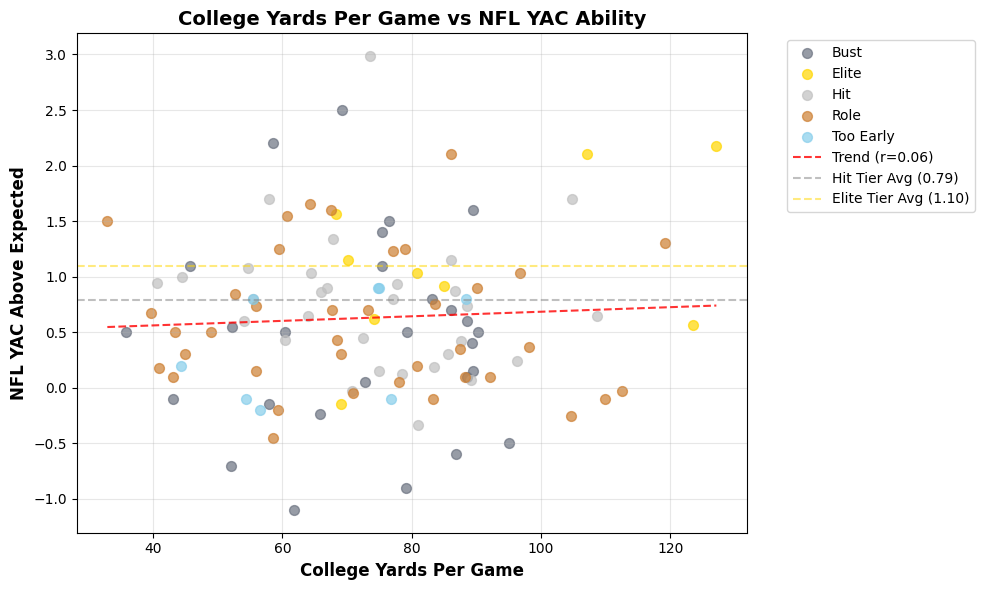


COLLEGE YPG VS YAC ABOVE EXPECTED

Correlation coefficient: 0.056

Average YPG by YAC Performance:
----------------------------------------
High YAC (≥0.79): 73.7 yards
Low YAC (<0.79):  73.6 yards
Difference:        0.1 yards

Average YAC by College YPG Groups:
----------------------------------------
Group                   Count    Avg YAC
----------------------------------------
Low YPG (<70)              48       0.64
Mid YPG (70-73)             5       0.32
High TDs (74-89)           43       0.64
Elite TDs (90+)            16       0.67


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# only players with both metrics
clean_data = results[['college_ypg', 'avg_yac_above_expected', 'nfl_tier']].dropna()

print(f"Players with both college ypg and NFL YAC data: {len(clean_data)}")
print(f"Total players in dataset: {len(results)}")
print(f"Missing data: {len(results) - len(clean_data)} players\n")


fig, ax = plt.subplots(figsize=(10, 6))

# define tier colors
tier_colors = {
    'Elite': '#FFD700',
    'Hit': '#C0C0C0', 
    'Role': '#CD7F32',
    'Bust': '#6B7280',
    'Too Early': '#87CEEB'
}

# plot each tier separately
for tier in clean_data['nfl_tier'].unique():
    tier_data = clean_data[clean_data['nfl_tier'] == tier]
    ax.scatter(tier_data['college_ypg'], 
              tier_data['avg_yac_above_expected'],
              c=tier_colors.get(tier, '#333333'),
              label=tier,
              alpha=0.7,
              s=50)

# add trend line
z = np.polyfit(clean_data['college_ypg'], 
               clean_data['avg_yac_above_expected'], 1)
p = np.poly1d(z)
ax.plot(sorted(clean_data['college_ypg']), 
        p(sorted(clean_data['college_ypg'])), 
        "r--", alpha=0.8, label=f'Trend (r={np.corrcoef(clean_data["college_ypg"], clean_data["avg_yac_above_expected"])[0,1]:.2f})')

# Labels and formatting
ax.set_xlabel('College Yards Per Game', fontsize=12, fontweight='bold')
ax.set_ylabel('NFL YAC Above Expected', fontsize=12, fontweight='bold')
ax.set_title('College Yards Per Game vs NFL YAC Ability', fontsize=14, fontweight='bold')
ax.axhline(y=0.79, color='gray', linestyle='--', alpha=0.5, label='Hit Tier Avg (0.79)')
ax.axhline(y=1.10, color='#FFD700', linestyle='--', alpha=0.5, label='Elite Tier Avg (1.10)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# print key stats
print("COLLEGE YPG VS YAC ABOVE EXPECTED")
print("=" * 60)

# correlation
correlation = clean_data[['college_ypg', 'avg_yac_above_expected']].corr().iloc[0,1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

# break it down by YAC performance
print("\nAverage YPG by YAC Performance:")
print("-" * 40)
high_yac = clean_data[clean_data['avg_yac_above_expected'] >= 0.79]['college_ypg'].mean()
low_yac = clean_data[clean_data['avg_yac_above_expected'] < 0.79]['college_ypg'].mean()
print(f"High YAC (≥0.79): {high_yac:.1f} yards")
print(f"Low YAC (<0.79):  {low_yac:.1f} yards")
print(f"Difference:        {(high_yac - low_yac):.1f} yards")

# break it down by ypg groups
print("\nAverage YAC by College YPG Groups:")
print("-" * 40)
print(f"{'Group':<20} {'Count':>8} {'Avg YAC':>10}")
print("-" * 40)

# using your distribution from earlier 
groups = [
    ('Low YPG (<70)', clean_data['college_ypg'] < 70),
    ('Mid YPG (70-73)', (clean_data['college_ypg'] >= 70) & (clean_data['college_ypg'] < 73)),
    ('High TDs (74-89)', (clean_data['college_ypg'] >= 73) & (clean_data['college_ypg'] < 90)),
    ('Elite TDs (90+)', clean_data['college_ypg'] >= 90)
]

for group_name, mask in groups:
    group_data = clean_data[mask]
    if len(group_data) > 0:
        print(f"{group_name:<20} {len(group_data):>8} {group_data['avg_yac_above_expected'].mean():>10.2f}")

Players with both 40 time and NFL YAC data: 107
Total players in dataset: 292
Missing data: 185 players



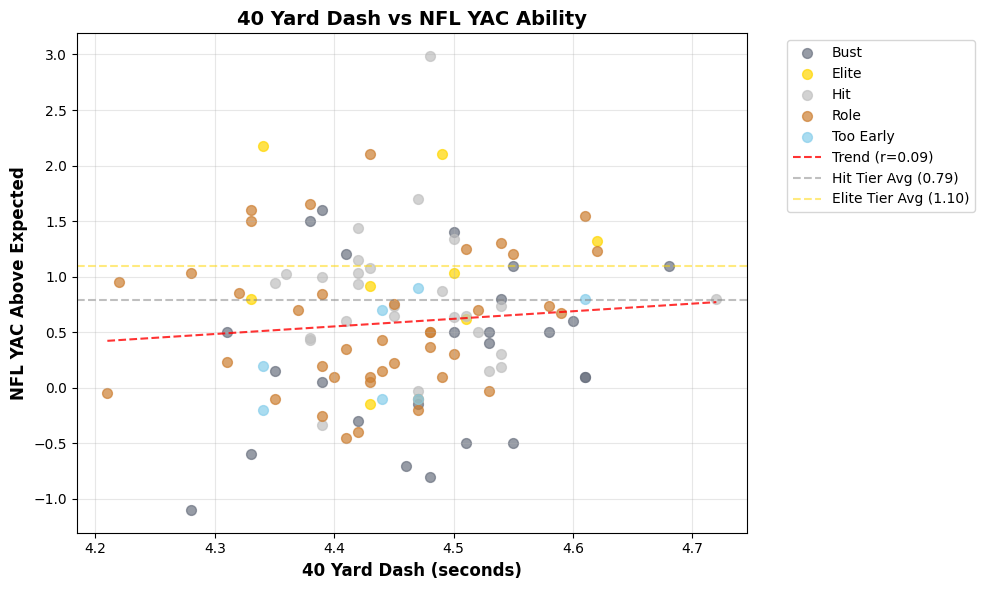

40 YARD DASH VS YAC ABOVE EXPECTED

Correlation coefficient: 0.092

Average 40 Time by YAC Performance:
----------------------------------------
High YAC (≥0.79): 4.45s
Low YAC (<0.79):  4.45s
Difference:        -0.00s

Average YAC by 40 Time Groups:
----------------------------------------
Group                   Count    Avg YAC
----------------------------------------
Elite (<4.4)               30       0.59
Very Fast (4.4-4.5)        41       0.52
Fast (4.5-4.6)             27       0.61
Average (>4.6)              9       0.85


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# only players with both metrics
clean_data = results[['forty_time', 'avg_yac_above_expected', 'nfl_tier']].dropna()

print(f"Players with both 40 time and NFL YAC data: {len(clean_data)}")
print(f"Total players in dataset: {len(results)}")
print(f"Missing data: {len(results) - len(clean_data)} players\n")

fig, ax = plt.subplots(figsize=(10, 6))

# tier colors
tier_colors = {
    'Elite': '#FFD700',
    'Hit': '#C0C0C0', 
    'Role': '#CD7F32',
    'Bust': '#6B7280',
    'Too Early': '#87CEEB'
}

# plot each tier separately
for tier in clean_data['nfl_tier'].unique():
    tier_data = clean_data[clean_data['nfl_tier'] == tier]
    ax.scatter(tier_data['forty_time'], 
              tier_data['avg_yac_above_expected'],
              c=tier_colors.get(tier, '#333333'),
              label=tier,
              alpha=0.7,
              s=50)

# add trend line
z = np.polyfit(clean_data['forty_time'], 
               clean_data['avg_yac_above_expected'], 1)
p = np.poly1d(z)
ax.plot(sorted(clean_data['forty_time']), 
        p(sorted(clean_data['forty_time'])), 
        "r--", alpha=0.8, label=f'Trend (r={np.corrcoef(clean_data["forty_time"], clean_data["avg_yac_above_expected"])[0,1]:.2f})')

# labels and formatting
ax.set_xlabel('40 Yard Dash (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('NFL YAC Above Expected', fontsize=12, fontweight='bold')
ax.set_title('40 Yard Dash vs NFL YAC Ability', fontsize=14, fontweight='bold')
ax.axhline(y=0.79, color='gray', linestyle='--', alpha=0.5, label='Hit Tier Avg (0.79)')
ax.axhline(y=1.10, color='#FFD700', linestyle='--', alpha=0.5, label='Elite Tier Avg (1.10)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key stats
print("40 YARD DASH VS YAC ABOVE EXPECTED")
print("=" * 60)

# correlation
correlation = clean_data[['forty_time', 'avg_yac_above_expected']].corr().iloc[0,1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

# break it down by YAC performance
print("\nAverage 40 Time by YAC Performance:")
print("-" * 40)
high_yac = clean_data[clean_data['avg_yac_above_expected'] >= 0.79]['forty_time'].mean()
low_yac = clean_data[clean_data['avg_yac_above_expected'] < 0.79]['forty_time'].mean()
print(f"High YAC (≥0.79): {high_yac:.2f}s")
print(f"Low YAC (<0.79):  {low_yac:.2f}s")
print(f"Difference:        {(high_yac - low_yac):.2f}s")

# break it down by 40 time groups (using common thresholds)
print("\nAverage YAC by 40 Time Groups:")
print("-" * 40)
print(f"{'Group':<20} {'Count':>8} {'Avg YAC':>10}")
print("-" * 40)

# standard 40 time thresholds
groups = [
    ('Elite (<4.4)', clean_data['forty_time'] < 4.4),
    ('Very Fast (4.4-4.5)', (clean_data['forty_time'] >= 4.4) & (clean_data['forty_time'] < 4.5)),
    ('Fast (4.5-4.6)', (clean_data['forty_time'] >= 4.5) & (clean_data['forty_time'] < 4.6)),
    ('Average (>4.6)', clean_data['forty_time'] >= 4.6)
]

for group_name, mask in groups:
    group_data = clean_data[mask]
    if len(group_data) > 0:
        print(f"{group_name:<20} {len(group_data):>8} {group_data['avg_yac_above_expected'].mean():>10.2f}")

Players with both 3-cone and NFL YAC data: 56
Total players in dataset: 292
Missing data: 236 players



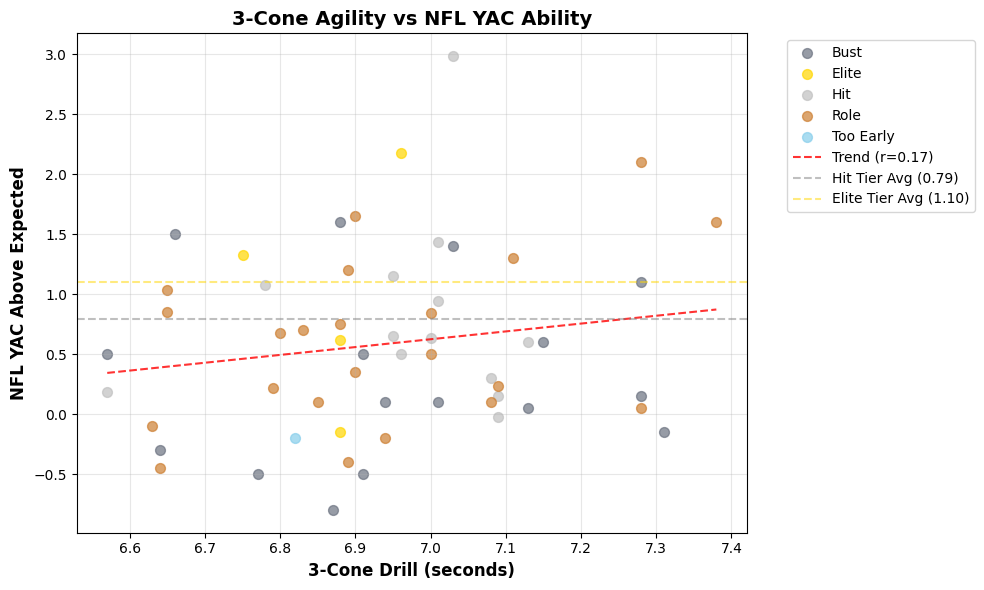

3-CONE DRILL VS YAC ABOVE EXPECTED

Correlation coefficient: 0.168

Average 3-Cone Time by YAC Performance:
----------------------------------------
High YAC (≥0.79): 6.96s
Low YAC (<0.79):  6.93s
Difference:        0.02s

Average YAC by 3-Cone Groups:
----------------------------------------
Group                   Count    Avg YAC
----------------------------------------
Elite Agility (<6.82)       13       0.46
Good Agility (6.82-6.98)       20       0.49
Avg Agility (6.98-7.10)       13       0.74
Poor Agility (>7.10)       10       0.74


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# only players with both metrics
clean_data = results[['cone', 'avg_yac_above_expected', 'nfl_tier']].dropna()

print(f"Players with both 3-cone and NFL YAC data: {len(clean_data)}")
print(f"Total players in dataset: {len(results)}")
print(f"Missing data: {len(results) - len(clean_data)} players\n")

fig, ax = plt.subplots(figsize=(10, 6))

# tier colors
tier_colors = {
    'Elite': '#FFD700',
    'Hit': '#C0C0C0', 
    'Role': '#CD7F32',
    'Bust': '#6B7280',
    'Too Early': '#87CEEB'
}

# plot each tier separately
for tier in clean_data['nfl_tier'].unique():
    tier_data = clean_data[clean_data['nfl_tier'] == tier]
    ax.scatter(tier_data['cone'], 
              tier_data['avg_yac_above_expected'],
              c=tier_colors.get(tier, '#333333'),
              label=tier,
              alpha=0.7,
              s=50)

# add trend line
z = np.polyfit(clean_data['cone'], 
               clean_data['avg_yac_above_expected'], 1)
p = np.poly1d(z)
ax.plot(sorted(clean_data['cone']), 
        p(sorted(clean_data['cone'])), 
        "r--", alpha=0.8, label=f'Trend (r={np.corrcoef(clean_data["cone"], clean_data["avg_yac_above_expected"])[0,1]:.2f})')

# labels and formatting
ax.set_xlabel('3-Cone Drill (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('NFL YAC Above Expected', fontsize=12, fontweight='bold')
ax.set_title('3-Cone Agility vs NFL YAC Ability', fontsize=14, fontweight='bold')
ax.axhline(y=0.79, color='gray', linestyle='--', alpha=0.5, label='Hit Tier Avg (0.79)')
ax.axhline(y=1.10, color='#FFD700', linestyle='--', alpha=0.5, label='Elite Tier Avg (1.10)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# print key stats
print("3-CONE DRILL VS YAC ABOVE EXPECTED")
print("=" * 60)

# correlation
correlation = clean_data[['cone', 'avg_yac_above_expected']].corr().iloc[0,1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

# break it down by YAC performance
print("\nAverage 3-Cone Time by YAC Performance:")
print("-" * 40)
high_yac = clean_data[clean_data['avg_yac_above_expected'] >= 0.79]['cone'].mean()
low_yac = clean_data[clean_data['avg_yac_above_expected'] < 0.79]['cone'].mean()
print(f"High YAC (≥0.79): {high_yac:.2f}s")
print(f"Low YAC (<0.79):  {low_yac:.2f}s")
print(f"Difference:        {(high_yac - low_yac):.2f}s")

# break it down by cone time groups (using your distribution from earlier)
print("\nAverage YAC by 3-Cone Groups:")
print("-" * 40)
print(f"{'Group':<20} {'Count':>8} {'Avg YAC':>10}")
print("-" * 40)

# using distribution from earlier (25th=6.82, 50th=6.98, 75th=7.10)
groups = [
    ('Elite Agility (<6.82)', clean_data['cone'] < 6.82),
    ('Good Agility (6.82-6.98)', (clean_data['cone'] >= 6.82) & (clean_data['cone'] < 6.98)),
    ('Avg Agility (6.98-7.10)', (clean_data['cone'] >= 6.98) & (clean_data['cone'] < 7.10)),
    ('Poor Agility (>7.10)', clean_data['cone'] >= 7.10)
]

for group_name, mask in groups:
    group_data = clean_data[mask]
    if len(group_data) > 0:
        print(f"{group_name:<20} {len(group_data):>8} {group_data['avg_yac_above_expected'].mean():>10.2f}")

Players with both broad jump and NFL YAC data: 104
Total players in dataset: 292
Missing data: 188 players



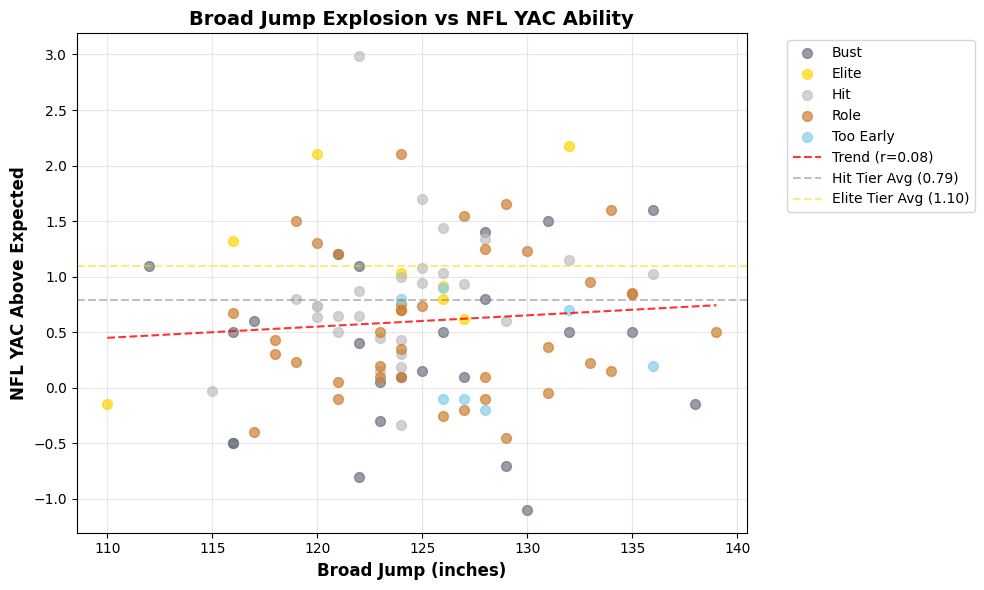

BROAD JUMP VS YAC ABOVE EXPECTED

Correlation coefficient: 0.084

Average Broad Jump by YAC Performance:
----------------------------------------
High YAC (≥0.79): 126.1"
Low YAC (<0.79):  124.5"
Difference:        1.6"

Average YAC by Broad Jump Groups:
----------------------------------------
Group                   Count    Avg YAC
----------------------------------------
Low Explosion (<121")       20       0.57
Avg Explosion (121-124")       33       0.55
Good Explosion (125-128")       26       0.67
Elite Explosion (>128")       25       0.63


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# only players with both metrics
clean_data = results[['broad_jump', 'avg_yac_above_expected', 'nfl_tier']].dropna()

print(f"Players with both broad jump and NFL YAC data: {len(clean_data)}")
print(f"Total players in dataset: {len(results)}")
print(f"Missing data: {len(results) - len(clean_data)} players\n")

fig, ax = plt.subplots(figsize=(10, 6))

# tier colors
tier_colors = {
    'Elite': '#FFD700',
    'Hit': '#C0C0C0', 
    'Role': '#CD7F32',
    'Bust': '#6B7280',
    'Too Early': '#87CEEB'
}

# plot each tier separately
for tier in clean_data['nfl_tier'].unique():
    tier_data = clean_data[clean_data['nfl_tier'] == tier]
    ax.scatter(tier_data['broad_jump'], 
              tier_data['avg_yac_above_expected'],
              c=tier_colors.get(tier, '#333333'),
              label=tier,
              alpha=0.7,
              s=50)

# add trend line
z = np.polyfit(clean_data['broad_jump'], 
               clean_data['avg_yac_above_expected'], 1)
p = np.poly1d(z)
ax.plot(sorted(clean_data['broad_jump']), 
        p(sorted(clean_data['broad_jump'])), 
        "r--", alpha=0.8, label=f'Trend (r={np.corrcoef(clean_data["broad_jump"], clean_data["avg_yac_above_expected"])[0,1]:.2f})')

# labels and formatting
ax.set_xlabel('Broad Jump (inches)', fontsize=12, fontweight='bold')
ax.set_ylabel('NFL YAC Above Expected', fontsize=12, fontweight='bold')
ax.set_title('Broad Jump Explosion vs NFL YAC Ability', fontsize=14, fontweight='bold')
ax.axhline(y=0.79, color='gray', linestyle='--', alpha=0.5, label='Hit Tier Avg (0.79)')
ax.axhline(y=1.10, color='#FFD700', linestyle='--', alpha=0.5, label='Elite Tier Avg (1.10)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# print key stats
print("BROAD JUMP VS YAC ABOVE EXPECTED")
print("=" * 60)

# correlation
correlation = clean_data[['broad_jump', 'avg_yac_above_expected']].corr().iloc[0,1]
print(f"\nCorrelation coefficient: {correlation:.3f}")

# break it down by YAC performance
print("\nAverage Broad Jump by YAC Performance:")
print("-" * 40)
high_yac = clean_data[clean_data['avg_yac_above_expected'] >= 0.79]['broad_jump'].mean()
low_yac = clean_data[clean_data['avg_yac_above_expected'] < 0.79]['broad_jump'].mean()
print(f"High YAC (≥0.79): {high_yac:.1f}\"")
print(f"Low YAC (<0.79):  {low_yac:.1f}\"")
print(f"Difference:        {(high_yac - low_yac):.1f}\"")

# break it down by broad jump groups (using distribution from earlier)
print("\nAverage YAC by Broad Jump Groups:")
print("-" * 40)
print(f"{'Group':<20} {'Count':>8} {'Avg YAC':>10}")
print("-" * 40)

# using distribution from earlier (25th=121, 50th=124, 75th=128)
groups = [
    ('Low Explosion (<121")', clean_data['broad_jump'] < 121),
    ('Avg Explosion (121-124")', (clean_data['broad_jump'] >= 121) & (clean_data['broad_jump'] < 125)),
    ('Good Explosion (125-128")', (clean_data['broad_jump'] >= 125) & (clean_data['broad_jump'] < 129)),
    ('Elite Explosion (>128")', clean_data['broad_jump'] >= 129)
]

for group_name, mask in groups:
    group_data = clean_data[mask]
    if len(group_data) > 0:
        print(f"{group_name:<20} {len(group_data):>8} {group_data['avg_yac_above_expected'].mean():>10.2f}")

## Key Findings: What Actually Predicts YAC Ability?

After running six scatter plots comparing college stats and combine metrics against NFL YAC above expected, the results are surprisingly clear: **Traditional athletic testing tells us almost nothing about who will excel after the catch.**

Here's what the numbers actually show:

### 1. Combine Metrics: Mostly Noise

All three combine drills posted weak correlation coefficients, but the story gets more interesting when you dig into the groups:

**40 Yard Dash (r = 0.092)**
- High YAC and Low YAC groups had the **exact same average 40 time** (4.45s)
- The highest YAC group? Players running **slower than 4.6** (0.85 YAC, n=9)
- Speed alone doesn't create YAC—if anything, the data suggests slower players might rely more on craft after the catch

**3-Cone Drill (r = 0.168)**
- The correlation is actually decent—just in the **wrong direction**
- Elite agility (<6.82s): 0.46 YAC
- Poor agility (>7.10s): 0.74 YAC
- The guys who need to make defenders miss in short areas? They're the ones actually doing it

**Broad Jump (r = 0.084)**
- Weakest correlation coefficient, but the biggest gap between high/low YAC groups (1.6 inches)
- Good explosion (125-128"): 0.67 YAC
- Low explosion (<121"): 0.57 YAC
- Explosive power might matter—the numbers just don't show a clean linear relationship

### 2. College Production: Where the Signals Hide

**Yards Per Catch (r = 0.153)**
The strongest signal in the entire dataset. Players who averaged over 16.7 YPC in college posted 0.90 YAC in the NFL—**0.21 higher than any other group**. Deep threat ability translates to YAC ability.

**Peak College TDs (r = 0.110)**
- Low TDs (<7): 0.38 YAC (by far the worst)
- Every other group: 0.59-0.86 YAC
- **The takeaway:** If you didn't score in college, you probably won't create after the catch in the NFL. But once you hit a certain threshold (~7 TDs), the relationship plateaus.

**College YPG (r = 0.056)**
Essentially no relationship. Volume production in college doesn't tell us anything about YAC ability.

### 3. The Bottom Line

**Athletic testing is overrated for predicting YAC.** The guys with elite 40 times, cone drills, and broad jumps aren't the ones consistently creating after the catch. If anything, the data suggests craft and production matter more than explosiveness.

**What actually matters:**
- **Yards per catch** — Deep threat college receivers become YAC threats in the NFL
- **Touchdowns** — If you can't find the end zone in college, you probably won't after the catch
- **Being "slow"** — The >4.6 group had the highest YAC (small sample caveat, but interesting)

**What doesn't matter:**
- 40 yard dash
- College yards per game
- 3-cone (or at least, not in the way scouts think)

***

## Looking Ahead: From Analysis to Prediction

After four notebooks of exploratory analysis, we've built a comprehensive understanding of what separates NFL wide receiver prospects:

### What We've Learned So Far

**Notebook 01: Draft Capital Matters**
- Round 1 is the only reliable source of elite talent (16.2% elite rate)
- Round 2 offers the best value (78.0% become starters)
- After Round 3, bust rates spike above 70%

**Notebook 02: College Production Alone Doesn't Drive Draft Position**
- Elite college producers (90+ YPG) appear in every round
- The 50-70 YPG baseline is consistent across almost all rounds
- Something else is driving those final draft-day decisions

**Notebook 03: Speed Is the Strongest Predictor of Draft Capital**
- 40-yard dash time (r = 0.38) correlates more with draft position than any college metric
- First-round picks are overwhelmingly from Power 5 conferences
- The "perfect profile" (elite speed + elite production + Power 5) is a first-round lock

**Notebook 04: YAC Above Expected Separates NFL Tiers**
- Elite receivers average 1.10 YAC above expected vs. Busts at 0.33
- But traditional athletic testing (40 time, 3-cone, broad jump) shows weak correlation with YAC ability
- College production—specifically yards per catch and touchdowns—tells us more about who will create after the catch

### The Natural Next Question

We now know:
- What gets players drafted (speed, conference pedigree)
- What separates NFL tiers once they're in the league (YAC above expected)
- Which college stats predict YAC ability (yards per catch, touchdowns)

**But can we combine all of this into a model that actually predicts success?**

### Coming in Notebook 05: Predictive Modeling

I'll build a simple classification model that takes pre-draft data—college production, combine athletic testing, conference, and draft capital—and predicts which tier (Elite/Hit/Role/Bust) a receiver will fall into.

This isn't about creating a black box. It's about answering:
- Which features does the model rely on most?
- Can we identify "bust" warning signs before the draft?
- Is there a "formula" for finding elite receivers outside Round 1?

After four notebooks of asking "what correlates with what," it's time to ask: **can we actually predict it?**

***
## LINKS <br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)